In [1]:
import pandas as pd
import seaborn as sns
import sqlite3

In [2]:
# Load dataset
df = sns.load_dataset('titanic')

In [5]:
# DATA QUALITY CHECKS

quality_report = pd.DataFrame({
    "missing_values": df.isnull().sum(),
    "missing_percent": (df.isnull().sum()/len(df))*100,
    "unique_values": df.nunique()
})
print("DATA QUALITY REPORT")
print(quality_report)

DATA QUALITY REPORT
             missing_values  missing_percent  unique_values
survived                  0         0.000000              2
pclass                    0         0.000000              3
sex                       0         0.000000              2
age                     177        19.865320             88
sibsp                     0         0.000000              7
parch                     0         0.000000              7
fare                      0         0.000000            248
embarked                  2         0.224467              3
class                     0         0.000000              3
who                       0         0.000000              3
adult_male                0         0.000000              2
deck                    688        77.216611              7
embark_town               2         0.224467              3
alive                     0         0.000000              2
alone                     0         0.000000              2


In [6]:
# CLEANING

df_clean = df.copy()
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])


In [7]:
# SQLITE (Simulating Snowflake)

conn = sqlite3.connect("vendor_risk.db")
df_clean.to_sql("vendors", conn, if_exists="replace", index=False)

query = """
SELECT sex, COUNT(*) as total,
AVG(age) as avg_age
FROM vendors
GROUP BY sex
"""

result = pd.read_sql(query, conn)
print(result)


      sex  total    avg_age
0  female    314  27.929936
1    male    577  30.140676


In [8]:
# EXPORTING RESULTS

df_clean.to_csv("vendor_clean_data.csv", index=False)
quality_report.to_csv("data_quality_report.csv")

In [9]:
import matplotlib.pyplot as plt

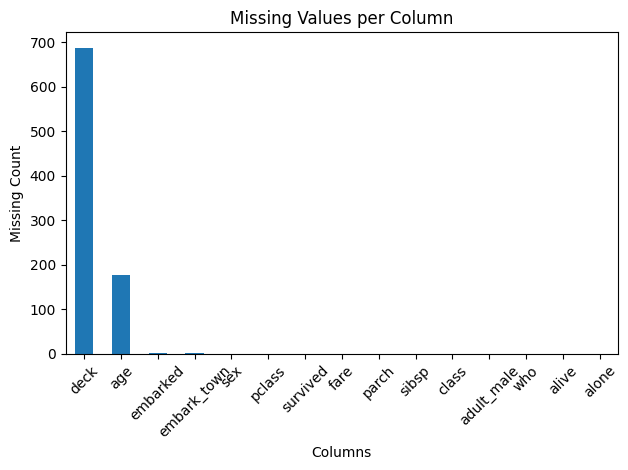

In [11]:
# MISSING VALUES BAR CHART

plt.figure()
df.isnull().sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

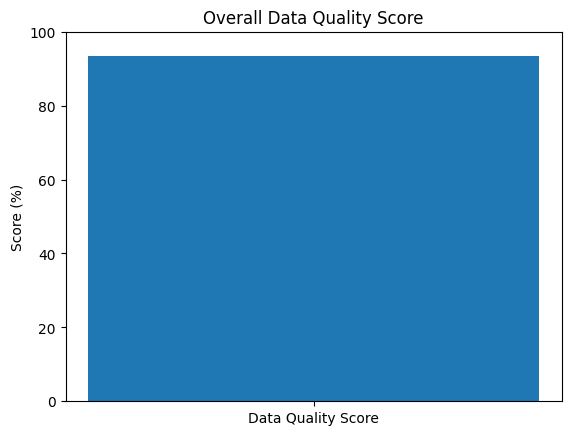

In [12]:
# DATA QUALITY SCORE VISUAL

quality_score = (1 - (df.isnull().sum() / len(df))).mean() * 100

plt.figure()
plt.bar(["Data Quality Score"], [quality_score])
plt.ylim(0, 100)
plt.title("Overall Data Quality Score")
plt.ylabel("Score (%)")
plt.show()